# Case management system analysis — social impact data science

**Tables:** `residents`, `process_recordings`, `home_visitations`, `education_records`, `health_wellbeing_records`, `intervention_plans`, `incident_reports`

This notebook maps the resident lifecycle, surfaces outcome and risk indicators, cross-domain patterns, early-warning signals, and operational recommendations (risk scoring, dashboards, data gaps).

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = Path("lighthouse_csv_v7")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Missing data folder: {DATA_DIR.resolve()}")

residents = pd.read_csv(
    DATA_DIR / "residents.csv",
    parse_dates=[
        "date_of_admission",
        "date_enrolled",
        "date_closed",
        "date_colb_registered",
        "date_colb_obtained",
        "created_at",
    ],
)
process_recordings = pd.read_csv(
    DATA_DIR / "process_recordings.csv", parse_dates=["session_date"]
)
home_visitations = pd.read_csv(
    DATA_DIR / "home_visitations.csv", parse_dates=["visit_date"]
)
education_records = pd.read_csv(
    DATA_DIR / "education_records.csv", parse_dates=["record_date"]
)
health_wellbeing_records = pd.read_csv(
    DATA_DIR / "health_wellbeing_records.csv", parse_dates=["record_date"]
)
intervention_plans = pd.read_csv(
    DATA_DIR / "intervention_plans.csv", parse_dates=["target_date", "created_at", "updated_at"]
)
incident_reports = pd.read_csv(
    DATA_DIR / "incident_reports.csv", parse_dates=["incident_date", "resolution_date"]
)

pd.DataFrame(
    {
        "rows": [
            len(residents),
            len(process_recordings),
            len(home_visitations),
            len(education_records),
            len(health_wellbeing_records),
            len(intervention_plans),
            len(incident_reports),
        ]
    },
    index=[
        "residents",
        "process_recordings",
        "home_visitations",
        "education_records",
        "health_wellbeing_records",
        "intervention_plans",
        "incident_reports",
    ],
)

,rows
residents,60
process_recordings,2819
home_visitations,1337
education_records,534
health_wellbeing_records,534
intervention_plans,180
incident_reports,100


## 1. Resident lifecycle: intake → intervention → progress → reintegration / closure

We approximate stages using **`residents`** dates and status fields, then layer longitudinal events (sessions, plans, visits).

,residents_reaching_stage
Intake (admission recorded),60
Intervention active (any plan row),60
Progress tracked (session or edu or health),60
Home / community contact (visit),58
Closure recorded (date_closed),30


Typical length of stay (closed cases, days):


,days_admission_to_close
count,30.000000
mean,445.100000
std,162.419073
min,191.000000
25%,286.750000
50%,431.000000
75%,583.000000
max,697.000000


Reintegration pipeline (all residents):


,n
reintegration_status,
In Progress,21
Completed,19
On Hold,13
Not Started,7


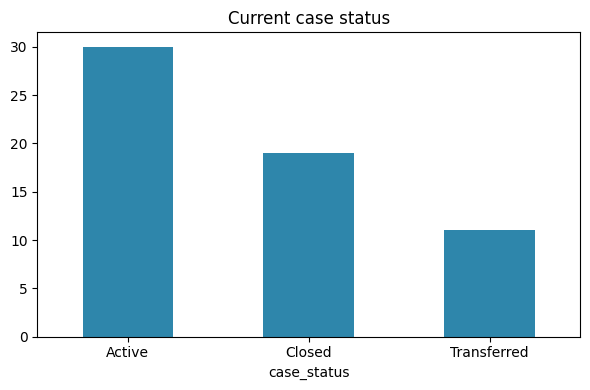

In [2]:
lifecycle = residents[
    [
        "resident_id",
        "case_status",
        "date_of_admission",
        "date_enrolled",
        "date_closed",
        "reintegration_type",
        "reintegration_status",
        "initial_risk_level",
        "current_risk_level",
    ]
].copy()

lifecycle["days_admission_to_close"] = (
    lifecycle["date_closed"] - lifecycle["date_of_admission"]
).dt.days

counts = {
    "Intake (admission recorded)": lifecycle["date_of_admission"].notna().sum(),
    "Intervention active (any plan row)": intervention_plans["resident_id"].nunique(),
    "Progress tracked (session or edu or health)": pd.concat(
        [
            process_recordings["resident_id"],
            education_records["resident_id"],
            health_wellbeing_records["resident_id"],
        ]
    ).nunique(),
    "Home / community contact (visit)": home_visitations["resident_id"].nunique(),
    "Closure recorded (date_closed)": lifecycle["date_closed"].notna().sum(),
}
display(pd.Series(counts).to_frame("residents_reaching_stage"))

print("Typical length of stay (closed cases, days):")
closed = lifecycle[lifecycle["date_closed"].notna()]["days_admission_to_close"]
display(closed.describe(percentiles=[0.25, 0.5, 0.75]).to_frame())

print("Reintegration pipeline (all residents):")
display(
    residents["reintegration_status"]
    .fillna("(missing)")
    .value_counts()
    .to_frame("n")
)

fig, ax = plt.subplots(figsize=(6, 4))
residents["case_status"].value_counts().plot(kind="bar", ax=ax, color="#2E86AB")
ax.set_title("Current case status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Lifecycle readout:** Intake is anchored on **`date_of_admission`** / **`date_enrolled`**. **Intervention** is visible in **`intervention_plans`** and **`process_recordings`** (services and session work). **Progress** shows up in **`education_records`** and **`health_wellbeing_records`** trajectories plus **`progress_noted`** in sessions. **Reintegration / closure** maps to **`reintegration_status`**, **`reintegration_type`**, **`case_status`**, and **`date_closed`**.

## 2. Indicators — positive outcomes vs high-risk cases

**Positive outcome (composite, explainable):**
- `reintegration_status == Completed` **or** `case_status == Closed` with completed reintegration where applicable  
- **Risk improvement:** ordinal drop from `initial_risk_level` → `current_risk_level`  
- **Education momentum:** positive slope of `progress_percent` over time (per resident)  
- **Health:** positive slope of `general_health_score` (per resident)  
- **Visits:** share of `visit_outcome == Favorable`

**High-risk (composite):**
- `current_risk_level` in {`Critical`, `High`}  
- Elevated **incident burden** (count, unresolved, High severity)  
- **Sessions:** `concerns_flagged` rate, negative emotional mix  
- **Visits:** `Unfavorable` / `Needs Improvement` / safety flags

Positive outcome score distribution (0–5 components):


,n_residents
positive_outcome_score,
1,3
2,18
3,22
4,14
5,3


High-risk flag (rule-based):


,n
high_risk_case,
True,51
False,9


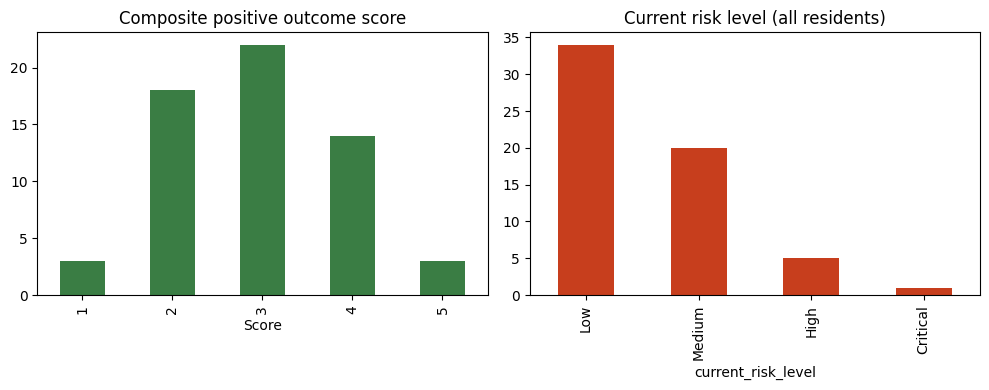

In [3]:
risk_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}

res = residents.copy()
res["risk_delta"] = res["initial_risk_level"].map(risk_map) - res["current_risk_level"].map(
    risk_map
)

res["positive_reintegration"] = res["reintegration_status"].eq("Completed")
res["risk_improved"] = res["risk_delta"] > 0

edu_slope = (
    education_records.sort_values(["resident_id", "record_date"])
    .groupby("resident_id")["progress_percent"]
    .apply(lambda s: np.polyfit(np.arange(len(s)), s.values, 1)[0] if len(s) > 2 else np.nan)
)
health_slope = (
    health_wellbeing_records.sort_values(["resident_id", "record_date"])
    .groupby("resident_id")["general_health_score"]
    .apply(lambda s: np.polyfit(np.arange(len(s)), s.values, 1)[0] if len(s) > 2 else np.nan)
)

visit_fav = home_visitations.groupby("resident_id", group_keys=False).apply(
    lambda g: (g["visit_outcome"] == "Favorable").mean(), include_groups=False
)

outcomes = res.set_index("resident_id")
outcomes["edu_progress_slope"] = edu_slope
outcomes["health_trend_slope"] = health_slope
outcomes["visit_favorable_rate"] = visit_fav

outcomes["positive_outcome_score"] = (
    outcomes["positive_reintegration"].astype(int)
    + outcomes["risk_improved"].astype(int)
    + (outcomes["edu_progress_slope"] > 0).fillna(False).astype(int)
    + (outcomes["health_trend_slope"] > 0).fillna(False).astype(int)
    + (outcomes["visit_favorable_rate"] >= 0.5).fillna(False).astype(int)
)

inc = incident_reports.groupby("resident_id").agg(
    n_incidents=("incident_id", "count"),
    n_high_sev=("severity", lambda s: (s == "High").sum()),
    n_unresolved=("resolved", lambda s: (~s.fillna(False)).sum()),
)

pr = process_recordings.groupby("resident_id").agg(
    n_sessions=("recording_id", "count"),
    concern_rate=("concerns_flagged", lambda s: s.fillna(False).mean()),
)

hv = home_visitations.groupby("resident_id").agg(
    unfavorable_rate=(
        "visit_outcome",
        lambda s: s.isin(["Unfavorable", "Needs Improvement"]).mean(),
    ),
)

risk_frame = outcomes.join(inc, how="left").join(pr, how="left").join(hv, how="left")
risk_frame[["n_incidents", "n_high_sev", "n_unresolved", "concern_rate", "unfavorable_rate"]] = (
    risk_frame[["n_incidents", "n_high_sev", "n_unresolved", "concern_rate", "unfavorable_rate"]]
    .fillna(0)
)

risk_frame["high_risk_case"] = (
    res.set_index("resident_id")["current_risk_level"].isin(["Critical", "High"])
) | (risk_frame["n_incidents"] >= risk_frame["n_incidents"].quantile(0.75)) | (
    risk_frame["unfavorable_rate"] >= 0.25
)

print("Positive outcome score distribution (0–5 components):")
display(risk_frame["positive_outcome_score"].value_counts().sort_index().to_frame("n_residents"))
print("High-risk flag (rule-based):")
display(risk_frame["high_risk_case"].value_counts().to_frame("n"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
risk_frame["positive_outcome_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#3A7D44"
)
axes[0].set_title("Composite positive outcome score")
axes[0].set_xlabel("Score")
res["current_risk_level"].value_counts().plot(kind="bar", ax=axes[1], color="#C73E1D")
axes[1].set_title("Current risk level (all residents)")
plt.tight_layout()
plt.show()

## 3. Patterns — incidents vs emotional state; education vs health vs interventions

We map **emotional_state_observed** to a numeric **valence** (higher = more distressed) and relate it to **incidents per resident**. We then build a **resident-level** correlation matrix: education trends, health trends, session intensity, plan completion mix.

Correlation: mean emotional valence vs incident count (resident level):
-0.3


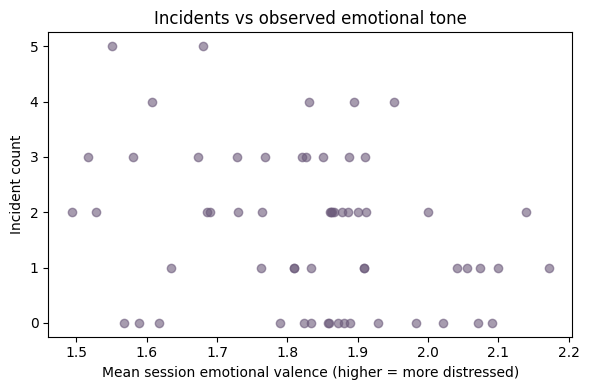

Cross-domain correlation (resident level):


,edu_slope,health_slope,n_sessions,plan_achieved_rate,incident_count
edu_slope,1.000,-0.054,-0.094,0.107,-0.269
health_slope,-0.054,1.000,-0.082,0.184,-0.063
n_sessions,-0.094,-0.082,1.000,-0.088,0.453
plan_achieved_rate,0.107,0.184,-0.088,1.000,-0.055
incident_count,-0.269,-0.063,0.453,-0.055,1.000


In [4]:
valence = {
    "Happy": 0,
    "Hopeful": 0.5,
    "Calm": 0.5,
    "Neutral": 1.0,
    "Sad": 2.0,
    "Anxious": 2.5,
    "Withdrawn": 2.5,
    "Distressed": 3.0,
    "Angry": 3.5,
}

proc = process_recordings.copy()
proc["emotional_valence"] = proc["emotional_state_observed"].map(valence)
emo_by_res = proc.groupby("resident_id")["emotional_valence"].mean()

inc_n = incident_reports.groupby("resident_id").size().rename("incident_count")
pattern = pd.concat([emo_by_res, inc_n], axis=1).fillna({"incident_count": 0})
print("Correlation: mean emotional valence vs incident count (resident level):")
print(round(pattern["emotional_valence"].corr(pattern["incident_count"]), 4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(pattern["emotional_valence"], pattern["incident_count"], alpha=0.6, color="#6C5B7B")
ax.set_xlabel("Mean session emotional valence (higher = more distressed)")
ax.set_ylabel("Incident count")
ax.set_title("Incidents vs observed emotional tone")
plt.tight_layout()
plt.show()

plan_status = intervention_plans.groupby("resident_id")["status"].apply(
    lambda s: (s == "Achieved").mean()
)
cross = pd.DataFrame(
    {
        "edu_slope": edu_slope,
        "health_slope": health_slope,
        "n_sessions": pr["n_sessions"],
        "plan_achieved_rate": plan_status,
        "incident_count": inc_n,
    }
).fillna(0)
print("Cross-domain correlation (resident level):")
display(cross.corr(numeric_only=True).round(3))

## 4. Early warning — escalating risk & failed reintegration

**Escalating risk (heuristic flags for ops):**
- **Incident velocity:** incidents in last 90 days vs prior 90 days (requires `AS_OF` from max event date).
- **Emotional trend:** linear trend of valence over last *n* sessions.
- **Stalled plans:** share of intervention plans `On Hold` or overdue vs `target_date`.
- **Visit friction:** rising `Unfavorable` / `Needs Improvement` or `safety_concerns_noted`.

**Failed / fragile reintegration (proxies):**
- `reintegration_status` in {`On Hold`, `Not Started`} for cases with long tenure  
- Low `visit_favorable_rate` combined with **active** `case_status`  
- Repeated **RunawayAttempt** / **SelfHarm** / unresolved **High** severity

In [5]:
AS_OF = pd.concat(
    [
        process_recordings["session_date"],
        home_visitations["visit_date"],
        incident_reports["incident_date"],
    ]
).max()
print("As-of (latest longitudinal event):", AS_OF.date())

cut_recent = AS_OF - pd.Timedelta(days=90)
cut_prior = AS_OF - pd.Timedelta(days=180)

inc_dt = incident_reports.copy()
inc_dt["recent"] = inc_dt["incident_date"] >= cut_recent
inc_dt["prior_window"] = (inc_dt["incident_date"] >= cut_prior) & (
    inc_dt["incident_date"] < cut_recent
)
vel = inc_dt.groupby("resident_id").apply(
    lambda g: pd.Series(
        {
            "inc_last_90d": g["recent"].sum(),
            "inc_prior_90d": g["prior_window"].sum(),
        }
    ),
    include_groups=False,
)
vel["velocity_flag"] = (vel["inc_last_90d"] > vel["inc_prior_90d"]) & (vel["inc_last_90d"] > 0)

proc_sorted = proc.sort_values(["resident_id", "session_date"])


def lastn_valence_trend(g, n=5):
    g = g.tail(n)
    if len(g) < 3:
        return np.nan
    x = np.arange(len(g))
    return np.polyfit(x, g["emotional_valence"].values, 1)[0]


emo_trend = proc_sorted.groupby("resident_id", group_keys=False).apply(
    lastn_valence_trend, include_groups=False
)

plan_stall = intervention_plans.assign(
    overdue=intervention_plans["target_date"] < AS_OF
).groupby("resident_id").apply(
    lambda g: pd.Series(
        {
            "pct_on_hold": (g["status"] == "On Hold").mean(),
            "pct_overdue": g["overdue"].mean(),
        }
    ),
    include_groups=False,
)

ew = pd.concat([vel, emo_trend.rename("emo_trend_last5"), plan_stall], axis=1).fillna(0)
ew["escalating_risk_flag"] = (ew["velocity_flag"]) | (ew["emo_trend_last5"] > 0.15) | (
    ew["pct_on_hold"] >= 0.5
)

long_tenure = (
    (AS_OF - residents.set_index("resident_id")["date_of_admission"]).dt.days > 365
)
reint_fragile = residents.set_index("resident_id")["reintegration_status"].isin(
    ["On Hold", "Not Started"]
)
visit_bad = outcomes["visit_favorable_rate"].fillna(1) < 0.4

bad_types = incident_reports[
    incident_reports["incident_type"].isin(["RunawayAttempt", "SelfHarm"])
].groupby("resident_id").size()

failed_proxy = (
    long_tenure & reint_fragile & visit_bad
).fillna(False) | (bad_types.reindex(residents["resident_id"]).fillna(0) >= 2)

print("Residents with escalating-risk heuristic:")
display(int(ew["escalating_risk_flag"].sum()))
print("Residents with fragile reintegration proxy:")
display(int(failed_proxy.sum()))

top_esc = ew[ew["escalating_risk_flag"]].sort_values(
    ["inc_last_90d", "pct_on_hold"], ascending=False
).head(10)
display(top_esc)

As-of (latest longitudinal event): 2027-02-02
Residents with escalating-risk heuristic:


27

Residents with fragile reintegration proxy:


16

,inc_last_90d,inc_prior_90d,velocity_flag,emo_trend_last5,pct_on_hold,pct_overdue,escalating_risk_flag
resident_id,,,,,,,
1,0.0,0.0,False,-1.500000e-01,0.666667,1.0,True
11,0.0,0.0,False,-4.827672e-16,0.666667,1.0,True
34,0.0,0.0,False,4.000000e-01,0.666667,1.0,True
35,0.0,0.0,False,1.000000e-01,0.666667,1.0,True
45,0.0,0.0,False,-6.000000e-01,0.666667,1.0,True
56,0.0,0.0,False,3.500000e-01,0.666667,1.0,True
43,0.0,0.0,0,-1.500000e-01,0.666667,1.0,True
49,0.0,0.0,0,1.500000e-01,0.666667,1.0,True
57,0.0,0.0,0,-3.000000e-01,0.666667,1.0,True


In [6]:
# Prototype 0–100 risk score: transparent weighted mix (min–max scaled per feature)
def _mm(a):
    a = np.asarray(a, dtype=float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    if hi - lo < 1e-9:
        return np.zeros_like(a)
    return (a - lo) / (hi - lo)


score_df = risk_frame[
    ["n_incidents", "concern_rate", "unfavorable_rate", "positive_outcome_score"]
].copy()
score_df["risk_level_ord"] = residents.set_index("resident_id")["current_risk_level"].map(risk_map)
Xn = np.column_stack(
    [
        _mm(score_df["n_incidents"].fillna(0).values),
        _mm(score_df["concern_rate"].fillna(0).values),
        _mm(score_df["unfavorable_rate"].fillna(0).values),
        _mm(score_df["risk_level_ord"].fillna(0).values),
        1.0 - _mm(score_df["positive_outcome_score"].fillna(0).values),
    ]
)
weights = np.array([0.25, 0.15, 0.2, 0.3, 0.1])
prototype_risk = (Xn * weights).sum(axis=1) * 100
out_risk = pd.DataFrame(
    {"prototype_risk_0_100": np.round(prototype_risk, 1)},
    index=risk_frame.index,
).sort_values("prototype_risk_0_100", ascending=False)
print("Top 10 prototype risk scores (higher = more concern):")
display(out_risk.head(10))

Top 10 prototype risk scores (higher = more concern):


,prototype_risk_0_100
resident_id,
12,65.8
41,62.0
30,61.0
1,58.6
8,53.6
25,51.7
17,50.0
55,45.7
44,45.5


---

## Recommendations — resident risk score (predictive + operational)

### Proposed **Resident Risk Score** (0–100, higher = worse)

| Component | Source | Notes |
|-----------|--------|--------|
| **Static severity** | `current_risk_level`, `initial_risk_level`, vulnerability flags (`is_pwd`, `has_special_needs`, case subcategories) | Ordinal encode + light weighting |
| **Behavioral / safety** | `incident_reports`: recency-weighted count, unresolved, High severity, Runaway/SelfHarm | Exponential decay by days |
| **Clinical / psychosocial trend** | `process_recordings`: emotional valence trend, `concerns_flagged` rate, referral_made | Last 90 days |
| **Plan execution** | `intervention_plans`: % On Hold, overdue vs `target_date`, % Achieved | Stalled plans raise score |
| **Reintegration readiness** | `home_visitations`: unfavorable rate, safety_concerns, cooperation | Family/system friction |
| **Whole-person functioning** | Slopes / levels from `education_records`, `health_wellbeing_records` | Declining attendance or health raises score |

**Modeling approach:** start with a **transparent weighted score** (calibrated to incident rate or adverse outcome in holdout); graduate to **gradient boosting** or **survival analysis** for "time to incident" or "failure to complete reintegration" once labels stabilize.

**Governance:** review score drivers in supervision (not auto-punitive); refresh weights quarterly; audit for bias across regions and case categories.

---

### Case worker dashboard metrics (operational)

- **Caseload risk:** mean & max resident risk score; count above threshold.
- **Touchpoint recency:** days since last `process_recording` / `home_visitation` per active resident.
- **Plan backlog:** open plans past `target_date`; % On Hold by `plan_category`.
- **Incident triage:** unresolved with `follow_up_required`; severity mix (7/14/30 days).
- **Trajectory tiles:** education `progress_percent` vs time; health composite vs time (sparklines).
- **Reintegration funnel:** counts by `reintegration_status` × tenure bucket.
- **Visit quality:** % Favorable vs unfavorable; safety flags per 10 visits.

---

### Missing data that would improve outcomes

- **Standardized clinical scores** (e.g. trauma/PHQ) on a schedule — not just free-text session notes.
- **School-reported grades / formal transcripts** to validate `education_records` self-reports.
- **Family permanency tracking** beyond visit cooperation — legal status, contact frequency, caregiver capacity.
- **Post-exit follow-up** (3/6/12 months) to label true reintegration success vs administrative closure.
- **Incident root-cause taxonomy** (triggers, antecedents) for better prevention than type/severity alone.
- **Inter-rater reliability** on `emotional_state_observed` and visit outcomes to reduce measurement noise.
- **Linkage across systems** — police, hospital, school IDs — for external validation (where ethically permitted).

---

**Predictive + operational synthesis:** Use the risk score to **prioritize rounds** and **supervision time**, while dashboards keep **throughput and quality** visible (plans on track, visits favorable, incidents resolving). Long-term, invest in **post-closure outcomes** and **structured assessments** so models learn from **real success**, not only in-facility stability.